# Copulas don't save you: Kelly portfolio instability under a fitted joint model, and how NCO does

A sequel to `8_nested_clustered_optimization.ipynb`. There we saw plain Markowitz overfit a noisy historical covariance matrix and collapse out of sample — *Markowitz's curse* — while Nested Clustered Optimization (NCO) survived.

A natural objection: *the problem was crude historical covariance; model the dependence properly with a copula and the instability goes away.* This notebook shows it does **not**. We fit a careful 19-asset joint model — Student-$t$ marginals plus a **Gaussian copula**, estimated on the training set — and then **maximize the Kelly criterion** (expected log growth). Even though the data-generating model is now *fixed*, the optimal Kelly weights swing violently from one simulated panel to the next. The instability lives in the **optimization step**, not in the dependence model. NCO, applied to the same fitted model, is structurally immune.

This reproduces — at 19 assets, through a copula — the optimization instability you met in the three-factor exercise (`6_refactor.ipynb`).

> **A note on the copula family.** We use a Gaussian copula here, not a $t$-copula. The choice is immaterial to the lesson: the instability comes from the Kelly optimizer inverting a noisy 19-asset dependence object, with $\widehat\Sigma^{-1}$-grade sensitivity, *whatever family generated it*. A Gaussian copula is also the only one we can fit cleanly at this dimension — its correlation matrix is estimated in closed form from normal-score correlations, whereas a full 19-dimensional $t$-copula joint MLE is numerically intractable (it does not converge in practical time). If anything, the Gaussian copula's lack of tail dependence makes this a *conservative* demonstration: a $t$-copula would punish the levered Kelly portfolio harder, not rescue it.

*Builds on the data and `cum_value` convention of notebook 8. With thanks to Joe Schneider for the original NCO example.*

## Estimation instability and resampling instability are the same amplifier

The optimizer is a map $\text{data} \to w^\star$. Kelly chooses $w$ to maximize $\mathbb{E}[\log(1 + g)]$ where $g$ is portfolio growth; the optimum bets the *estimated* edge, so $w^\star$ is extraordinarily sensitive to estimation noise (the same $\widehat\Sigma^{-1}$-grade amplification behind Markowitz's curse). That single sensitivity appears under two perturbations:

- **Estimation instability** — perturbation is *sampling error in real data*. Different historical windows give different $w^\star$; the trained portfolio fails out of sample. (Notebook 8's real-data OOS plot.)
- **Resampling instability** — perturbation is *Monte-Carlo error in synthetic draws from a fixed fitted model*. The model is held constant; only the simulation seed changes; $w^\star$ still swings.

Resampling instability is the **controlled proof of the mechanism** — it removes the "the world changed" escape hatch, isolating the optimizer's noise amplification. Estimation instability is the same amplifier fed by real sampling noise. We lead with resampling (the *why*) and close with the notebook-8-style real-data OOS plot (the *so what*).

## What we deliberately do not do, and why

- **No model selection.** We fix one marginal family (Student-$t$, ML-fit per asset) for all 19 risky assets. Choosing among families is the subject of notebooks 3–5; here it would distract from the optimization point.
- **No tail clip.** Notebook `6_refactor` clipped simulated draws at 2× the historical loss, which *defangs* exactly the resampling instability we want to exhibit. We let the fitted copula and $t$-marginals produce their natural tails.
- **Risk-free asset held out.** Column 20 is near-constant; PIT and copula machinery degenerate on it. We model the 19 risky assets only and treat the risk-free asset deterministically, as the residual-budget rate $\bar r^f$ (training-set mean).
- **Full Kelly, leveraged.** $w$ is unconstrained (shorting and leverage allowed); the risk-free asset absorbs the residual budget $1-\sum w$. Full Kelly with leverage is the *sharpest* version of the instability — and it requires a ruin guard, since $1+g$ can go non-positive.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(778)  # mirrors notebook 8 / Random.seed!(778)

## Data

Same `vmls_portfolio_returns.csv` as notebook 8: 2500 daily returns, 20 assets, split chronologically into a 2000-day training set and a non-overlapping 500-day test set. Columns 1–19 are risky stocks; column 20 is the risk-free asset, which we separate out.

In [2]:
returns = pd.read_csv("vmls_portfolio_returns.csv").to_numpy()
R_all      = returns[:2000, :]
R_all_test = returns[2000:, :]

R      = R_all[:, :19]          # 19 risky, training
R_test = R_all_test[:, :19]     # 19 risky, test
rf_bar = R_all[:, 19].mean()    # deterministic residual-budget risk-free rate

T, p = R.shape
T_test = R_test.shape[0]
print(f"risky training R : {R.shape}")
print(f"risky test R_test: {R_test.shape}")
print(f"residual risk-free rate (train mean): {rf_bar:.3e} per day  (~{250*rf_bar:.2%}/yr)")

risky training R : (2000, 19)
risky test R_test: (500, 19)
residual risk-free rate (train mean): 4.000e-05 per day  (~1.00%/yr)


## The Kelly optimizer (replaces notebook 8's mean-variance `port_opt`)

With signed weights $w \in \mathbb{R}^{m}$ on $m$ risky assets and the risk-free asset absorbing the residual budget, per-period growth is

$$
g_t(w) \;=\; \Big(1 - \textstyle\sum_j w_j\Big)\,\bar r^f \;+\; \sum_{j} w_j\, r_{t,j}.
$$

Full Kelly maximizes expected log growth. Leverage can drive $1+g_t \le 0$ (ruin); a literal $-\infty$ breaks the optimizer's line search, so — exactly as in `2_simple_portfolio_optimization.ipynb` and `6_refactor`'s `modified_crra_utility` — we floor the log argument at $\varepsilon$:

$$
\widehat{\text{NK}}(w) \;=\; -\,\frac{1}{T}\sum_t \log\!\big(\max(1+g_t(w),\,\varepsilon)\big).
$$

Because the risk-free asset absorbs the residual budget, $1+g_t(w) = (1+\bar r^f) + x_t^\top w$ with **excess returns** $x_{t,j}=r_{t,j}-\bar r^f$. That makes the objective smooth in $w$ with an analytic gradient $-\frac1T\sum_t x_t/(1+g_t)$, so we solve it with gradient-based **L-BFGS-B** — *much* faster and more accurate here than a derivative-free search (Nelder-Mead does not even converge in 19 dimensions in reasonable time). The same routine is used everywhere: the plain "all 19 at once" Kelly, and every within-cluster and across-cluster Kelly solve inside NCO — so NCO is genuinely the *nested* version of the same objective.

In [3]:
EPS = 1e-9

def gross_growth(w, Rm):
    # Rm: (T, m) risky returns; w: (m,). Risk-free absorbs the residual budget.
    w = np.asarray(w, float)
    return (1.0 - w.sum()) * rf_bar + Rm @ w

def _kelly_fg(Rm):
    """Return (objective, gradient) closures for the floored neg-Kelly on Rm."""
    X = Rm - rf_bar          # excess-return design: 1 + g = (1+rf_bar) + X@w
    base = 1.0 + rf_bar
    def f(w):
        a = np.maximum(base + X @ w, EPS)
        return -np.mean(np.log(a))
    def grad(w):
        a = np.maximum(base + X @ w, EPS)
        return -(X / a[:, None]).mean(axis=0)
    return f, grad

def neg_kelly(w, Rm):
    """Floored negative mean log-growth (scalar diagnostic)."""
    a = np.maximum(1.0 + gross_growth(w, Rm), EPS)
    return -np.mean(np.log(a))

def kelly_opt(Rm):
    """Full-Kelly weights for an arbitrary risky-return matrix (any # of columns)."""
    m = Rm.shape[1]
    f, grad = _kelly_fg(Rm)
    res = minimize(f, x0=np.zeros(m), jac=grad, method="L-BFGS-B",
                   options=dict(maxiter=2000))
    return res.x

### Sanity check on the training data

Run plain full-Kelly directly on the 19 historical training returns. We do not expect modest weights — that is the whole point — but it should solve and report finite growth.

In [4]:
w_hist = kelly_opt(R)
g_hist = gross_growth(w_hist, R)
print(f"sum|w| (gross leverage): {np.abs(w_hist).sum():.2f}")
print(f"net risky weight 1-(1-Sum w) invested risk-free residual: {1 - w_hist.sum():+.2f}")
print(f"in-sample mean log-growth: {np.mean(np.log(np.maximum(1+g_hist, EPS))):.5f}")
print(f"in-sample geometric annual return: {np.exp(250*np.mean(np.log(np.maximum(1+g_hist, EPS))))-1:.2%}")

sum|w| (gross leverage): 14.60
net risky weight 1-(1-Sum w) invested risk-free residual: -2.21
in-sample mean log-growth: 0.00220
in-sample geometric annual return: 73.38%


## Step 1 — Fit Student-$t$ marginals to each of the 19 training series

One family, ML-fit per asset. (Deliberately not selected — see preamble.)

In [5]:
marg = [stats.t.fit(R[:, j]) for j in range(p)]   # (df, loc, scale) per asset
marg_tbl = pd.DataFrame(marg, columns=["df", "loc", "scale"],
                        index=[f"stock_{j+1}" for j in range(p)])
marg_tbl.round(5)

,df,loc,scale
stock_1,1.79756,0.00038,0.01148
stock_2,1.34464,-0.00018,0.01055
stock_3,3.11874,0.00076,0.01220
stock_4,4.60100,0.00016,0.02175
stock_5,4.10474,0.00039,0.01134
stock_6,3.35239,0.00029,0.01353
stock_7,2.94306,0.00011,0.01158
stock_8,2.42335,0.00028,0.01393
stock_9,3.17173,0.00054,0.01281
stock_10,3.97836,0.00028,0.01451


## Step 2 — Probability integral transform (PIT) to uniforms

Push each asset's training returns through its fitted $t$ CDF. If the marginals fit reasonably, each column is approximately Uniform(0,1).

A full 19×19 PIT pairplot is unreadable (171 panels), so we show a representative **4×4 grid** for stocks 1, 2, 3, 10 — chosen to span the range of dependence (s1–s2 is strongly dependent; pairs involving s10 are weaker). This is the standard copula diagnostic: the **diagonal** is each asset's PIT histogram (should look flat ≈ Uniform(0,1) — the per-asset marginal-fit check), and the **off-diagonal** panels are pairwise PIT scatters (uniform margins, so any structure is pure dependence — strong pairs clump along the diagonal and into the corners; independent pairs fill the square evenly).

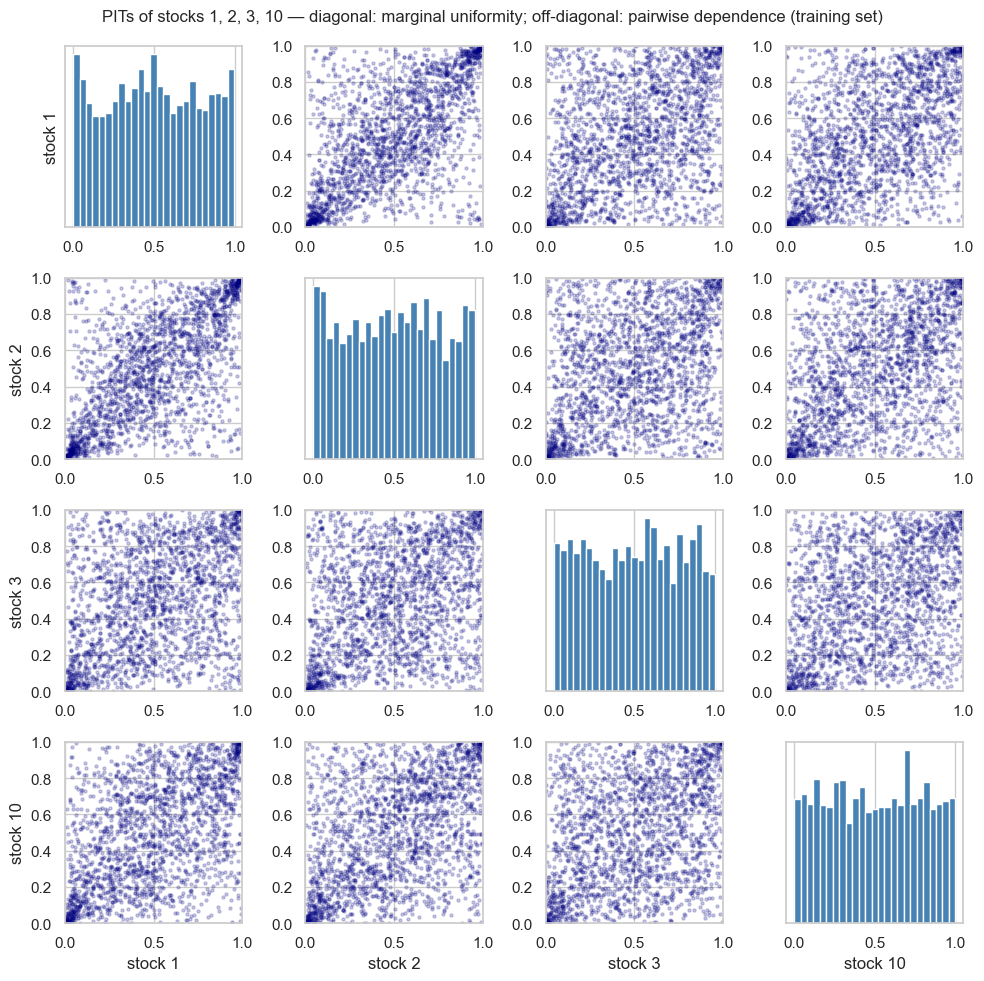

In [6]:
U = np.column_stack([stats.t.cdf(R[:, j], *marg[j]) for j in range(p)])
U = np.clip(U, 1e-6, 1 - 1e-6)   # keep the normal-score map away from the boundary

show = [0, 1, 2, 9]                       # stocks 1, 2, 3, 10 (0-indexed)
labels = [f"stock {j+1}" for j in show]
m = len(show)
fig, axes = plt.subplots(m, m, figsize=(10, 10))
for a in range(m):
    for b in range(m):
        ax = axes[a, b]
        ja, jb = show[a], show[b]
        if a == b:
            ax.hist(U[:, ja], bins=25, color="steelblue", edgecolor="white")
            ax.set_yticks([])
        else:
            ax.scatter(U[:, jb], U[:, ja], s=5, alpha=0.2, color="navy")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        if a == m - 1: ax.set_xlabel(labels[b])
        if b == 0:     ax.set_ylabel(labels[a])
fig.suptitle("PITs of stocks 1, 2, 3, 10 — diagonal: marginal uniformity; "
             "off-diagonal: pairwise dependence (training set)", fontsize=12)
fig.tight_layout(); plt.show()

## Step 3 — Fit a 19-dimensional Gaussian copula on the PITs

A Gaussian copula's only parameter is a correlation matrix $P$, estimated in closed form: map the PITs to normal scores $z_{t,j} = \Phi^{-1}(u_{t,j})$ and take their sample correlation. No iterative joint MLE — this is instantaneous and well-conditioned, in contrast to the full 19-dimensional $t$-copula whose joint MLE does not converge in practical time. We add a tiny eigenvalue floor so $P$ is numerically positive-definite (it has a Cholesky factor we reuse when simulating).

In [7]:
Z = stats.norm.ppf(U)                 # normal scores
P = np.corrcoef(Z, rowvar=False)      # closed-form Gaussian-copula correlation

# numerical PSD repair, then renormalize to unit diagonal
evals, evecs = np.linalg.eigh(P)
P = evecs @ np.diag(np.clip(evals, 1e-10, None)) @ evecs.T
dP = np.sqrt(np.diag(P))
P = P / np.outer(dP, dP)
chol_P = np.linalg.cholesky(P)        # reused by simulate_panel

print(f"Gaussian copula fitted: 19x19 correlation matrix, condition number {np.linalg.cond(P):.1f}")
print("dependence matrix, top-left 5x5:")
print(np.round(P[:5, :5], 3))

Gaussian copula fitted: 19x19 correlation matrix, condition number 36.7
dependence matrix, top-left 5x5:
[[1.    0.66  0.418 0.412 0.467]
 [0.66  1.    0.393 0.339 0.401]
 [0.418 0.393 1.    0.341 0.301]
 [0.412 0.339 0.341 1.    0.371]
 [0.467 0.401 0.301 0.371 1.   ]]


## Headline experiment — resampling instability

The joint model is now **fixed**. We draw many independent synthetic panels from `(Gaussian copula → inverse-t-PIT)`, and for each panel solve **(a)** plain full-Kelly on all 19 assets and **(b)** the full NCO pipeline. Because nothing about the model changes between panels, *any* variation in $w^\star$ is pure Monte-Carlo noise amplified by the optimizer.

`simulate_panel` draws `n_obs` correlated normal scores via the Cholesky factor of $P$, maps them to uniforms through $\Phi$, then inverts each coordinate through its fitted $t$ marginal.

In [8]:
def simulate_panel(n_obs, seed):
    g = np.random.default_rng(seed)
    Zsim = g.standard_normal((n_obs, p)) @ chol_P.T   # N(0, P) normal scores
    Usim = np.clip(stats.norm.cdf(Zsim), 1e-9, 1 - 1e-9)
    cols = [stats.t.ppf(Usim[:, j], *marg[j]) for j in range(p)]
    return np.column_stack(cols)

# quick shape/finiteness check
demo = simulate_panel(2000, 12345)
print("panel shape:", demo.shape, "| all finite:", np.isfinite(demo).all())

panel shape: (2000, 19) | all finite: True


### NCO on a simulated panel

Same recipe as notebook 8, but the inner optimizer is now `kelly_opt`: correlation-distance (MLDP p. 54) → $k$-means ($k=5$) → full-Kelly **within** each cluster → full-Kelly **across** the cluster return series. $k$-means is re-run per panel, so NCO's variation *includes* clustering variation — we will still see it is dramatically tighter than plain Kelly, not literally constant.

In [9]:
def codist(S):
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(0.5 * (1.0 - C))

def kmeans_(x, k, maxiters=100, tol=1e-5, seed=0):
    g = np.random.default_rng(seed)
    N, d = len(x), len(x[0])
    distances = np.zeros(N)
    assignment = g.integers(1, k + 1, size=N)
    reps = [np.zeros(d) for _ in range(k)]
    Jprev = np.inf
    for it in range(1, maxiters + 1):
        for j in range(1, k + 1):
            grp = np.where(assignment == j)[0]
            if len(grp) > 0:
                reps[j - 1] = np.mean([x[i] for i in grp], axis=0)
        for i in range(N):
            dd = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i] = min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances) ** 2 / N
        if it > 1 and abs(J - Jprev) < tol * J:
            break
        Jprev = J
    return assignment

K = 5

def nco_weights(Rm, seed):
    """Return full-19-asset weight vector implied by the NCO pipeline on Rm."""
    D = codist(Rm)
    x = [D[:, i] for i in range(Rm.shape[1])]
    labels = kmeans_(x, K, seed=seed)
    w_full = np.zeros(Rm.shape[1])
    cluster_series, cluster_idx = [], []
    for c in range(1, K + 1):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        w_in = kelly_opt(Rm[:, idx])
        w_full[idx] = w_in                       # tentative within-cluster weights
        cluster_series.append(Rm[:, idx] @ w_in) # cluster portfolio return series
        cluster_idx.append(idx)
    Pr = np.column_stack(cluster_series)
    w_across = kelly_opt(Pr)                      # allocate across cluster portfolios
    for a, idx in zip(w_across, cluster_idx):     # compose nested weights
        w_full[idx] *= a
    return w_full

### Run 30 resampled panels

In [10]:
N_PANELS = 30
N_OBS = 2000  # same length as the training set

plain_W, nco_W = [], []
plain_term, nco_term = [], []
plain_ruin = nco_ruin = 0

for s in range(N_PANELS):
    panel = simulate_panel(N_OBS, seed=1000 + s)

    w_p = kelly_opt(panel)
    w_n = nco_weights(panel, seed=2000 + s)
    plain_W.append(w_p)
    nco_W.append(w_n)

    # evaluate BOTH on the real held-out test returns (the honest test)
    gp = gross_growth(w_p, R_test)
    gn = gross_growth(w_n, R_test)
    plain_ruin += int(np.any(1 + gp <= 0))
    nco_ruin   += int(np.any(1 + gn <= 0))
    plain_term.append((10_000 * np.cumprod(np.maximum(1 + gp, EPS)))[-1])
    nco_term.append((10_000 * np.cumprod(np.maximum(1 + gn, EPS)))[-1])

plain_W = np.array(plain_W); nco_W = np.array(nco_W)
plain_term = np.array(plain_term); nco_term = np.array(nco_term)
print(f"done: {N_PANELS} panels")
print(f"panels with a ruin event on real test data — plain: {plain_ruin}, NCO: {nco_ruin}")

done: 30 panels
panels with a ruin event on real test data — plain: 0, NCO: 0


### Plot A — the weights themselves, across panels

Each line is one asset's weight trajectory across the 30 resampled panels. Plain Kelly's weights (left) fan across a huge range — the optimizer chases Monte-Carlo noise into large, sign-flipping, levered bets. NCO's weights (right) are visibly tighter: clustering shrinks the noisy cross-asset terms before they reach the optimizer. Note the very different $y$-axis scales.

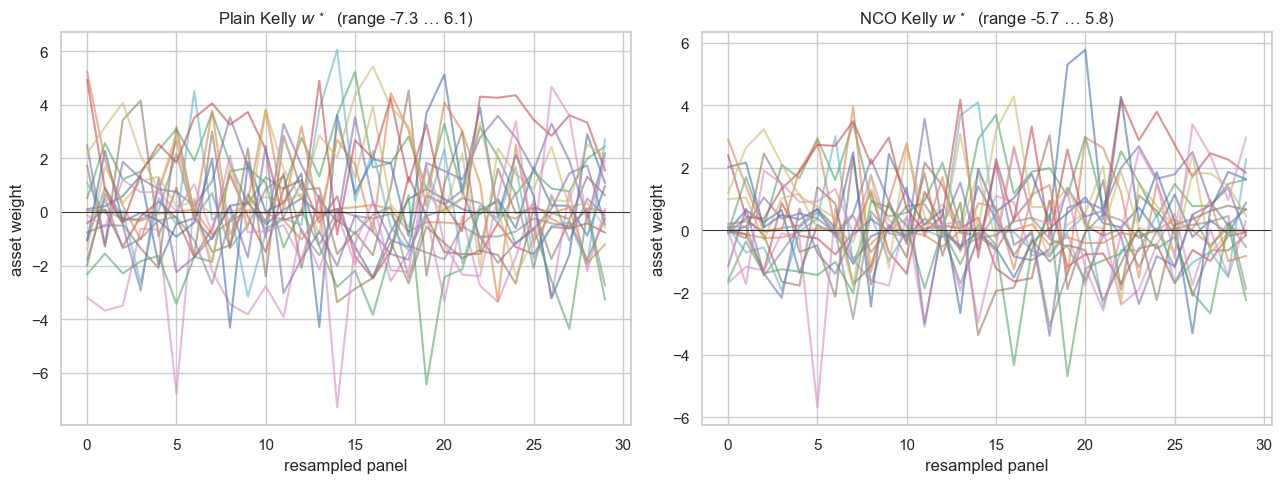

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for j in range(p):
    axes[0].plot(range(N_PANELS), plain_W[:, j], alpha=0.6)
    axes[1].plot(range(N_PANELS), nco_W[:, j], alpha=0.6)
axes[0].set_title(f"Plain Kelly $w^\star$  (range {plain_W.min():.1f} … {plain_W.max():.1f})")
axes[1].set_title(f"NCO Kelly $w^\star$  (range {nco_W.min():.1f} … {nco_W.max():.1f})")
for a in axes:
    a.set_xlabel("resampled panel"); a.set_ylabel("asset weight"); a.axhline(0, color="k", lw=.6)
plt.tight_layout(); plt.show()

### Plot B — real-data out-of-sample terminal wealth, across panels

For every panel we apply that panel's $w^\star$ to the **real** held-out 500-day test returns and record terminal wealth (\$10,000 start). Plain Kelly's outcomes are wide and frequently catastrophic; NCO's cluster tightly and far higher.

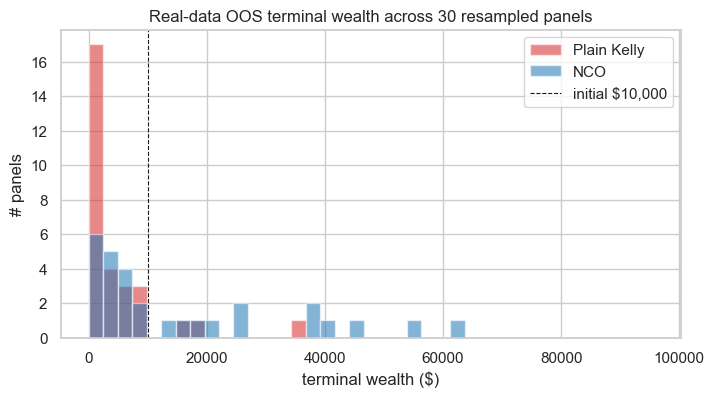

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(min(plain_term.min(), nco_term.min()),
                   np.percentile(np.concatenate([plain_term, nco_term]), 99), 40)
ax.hist(plain_term, bins=bins, alpha=0.55, label="Plain Kelly", color="tab:red")
ax.hist(nco_term,   bins=bins, alpha=0.55, label="NCO",         color="tab:blue")
ax.axvline(10_000, color="k", lw=.8, ls="--", label="initial $10,000")
ax.set_title("Real-data OOS terminal wealth across 30 resampled panels")
ax.set_xlabel("terminal wealth ($)"); ax.set_ylabel("# panels"); ax.legend(); plt.show()

In [13]:
def summ(W, term):
    return {
        "median |w| per asset": np.median(np.abs(W)),
        "max gross leverage sum|w|": np.max(np.abs(W).sum(axis=1)),
        "std of OOS terminal wealth": term.std(),
        "median OOS terminal wealth": np.median(term),
        "worst OOS terminal wealth": term.min(),
    }

stab = pd.DataFrame({"Plain Kelly": summ(plain_W, plain_term),
                     "NCO":         summ(nco_W,  nco_term)}).T
stab.style.format("{:,.2f}")

,median |w| per asset,max gross leverage sum|w|,std of OOS terminal wealth,median OOS terminal wealth,worst OOS terminal wealth
Plain Kelly,1.13,40.74,"7,180.19","1,637.15",2.48
NCO,0.73,29.86,"28,750.68","7,375.13",79.65


### Reading the experiment

The data-generating model never changed across the 30 panels — only the simulation seed did. Plain Kelly converts that pure Monte-Carlo noise into wildly different levered portfolios and a fat left tail of real-data outcomes. **Modeling the dependence with a copula did not help: the instability is in the optimization step.** NCO, fed the same noisy panels, stays tight because it never inverts the full ill-conditioned cross-asset structure — it optimizes small, well-conditioned sub-problems and nests them.

## Closer — the notebook-8 view: one representative panel, real-data OOS wealth path

For visual continuity with notebook 8, take a single representative panel, fit both portfolios, and plot the realized wealth path on the real held-out test set — the direct analogue of notebook 8's "Original vs NCO" figure, now under a fitted Gaussian-copula model and the Kelly objective.

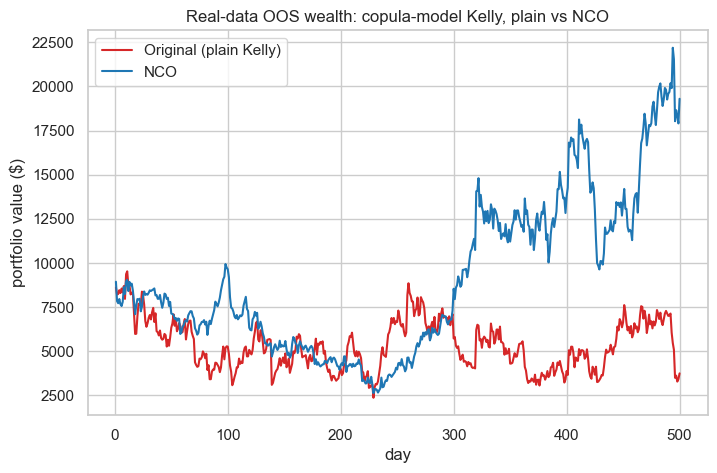

,final wealth ($),OOS gain,gross leverage sum|w|
Original (plain Kelly),"3,736.51",-62.63%,32.42
NCO,"19,299.31",92.99%,14.74


In [14]:
panel0 = simulate_panel(N_OBS, seed=1000)         # panel 0, same as the loop's first
w_plain0 = kelly_opt(panel0)
w_nco0   = nco_weights(panel0, seed=2000)

g_plain0 = gross_growth(w_plain0, R_test)
g_nco0   = gross_growth(w_nco0,   R_test)
V_plain  = 10_000 * np.cumprod(np.maximum(1 + g_plain0, EPS))
V_nco    = 10_000 * np.cumprod(np.maximum(1 + g_nco0,   EPS))

plt.figure(figsize=(8, 5))
plt.plot(range(1, T_test + 1), V_plain, label="Original (plain Kelly)", color="tab:red")
plt.plot(range(1, T_test + 1), V_nco,   label="NCO",                    color="tab:blue")
plt.title("Real-data OOS wealth: copula-model Kelly, plain vs NCO")
plt.xlabel("day"); plt.ylabel("portfolio value ($)")
plt.legend(loc="upper left"); plt.show()

closer = pd.DataFrame({
    "final wealth ($)": [V_plain[-1], V_nco[-1]],
    "OOS gain":         [V_plain[-1] / 10_000 - 1, V_nco[-1] / 10_000 - 1],
    "gross leverage sum|w|": [np.abs(w_plain0).sum(), np.abs(w_nco0).sum()],
}, index=["Original (plain Kelly)", "NCO"])
closer.style.format({"final wealth ($)": "{:,.2f}", "OOS gain": "{:.2%}",
                      "gross leverage sum|w|": "{:.2f}"})

## Synthesis

Kelly maximizes expected log growth, so $w^\star$ bets the *estimated* edge — exactly the quantity estimation noise corrupts, with $\widehat\Sigma^{-1}$-grade amplification. Giving the model a *better dependence structure* (a fitted copula instead of crude historical covariance) does not touch this: the resampling experiment holds the joint model fixed and the instability remains. The copula *family* is immaterial — a $t$-copula, were it tractable at 19 dimensions, would only sharpen the effect through tail dependence. This is the 19-asset, copula-modeled generalization of the three-factor instability in `6_refactor.ipynb`.

NCO fixes it **structurally**, not by better estimation: it never inverts the full ill-conditioned cross-asset object. It clusters by correlation distance, optimizes small well-conditioned sub-problems, and nests them — so Monte-Carlo noise stays local instead of being amplified across all 19 assets.

**Sequel (discussed, not coded here):** cross-validation with *purging and embargo*. When observations overlap in time a naive train/test split leaks information; MLDP's purged & embargoed CV removes training observations whose labels overlap the test window. That is the natural next notebook.